# Experimento 2 — Batch Normalization
## Comparação: sem BN vs BN-conv vs BN-conv+fc, sob SGD+momentum e Adam
### Design experimental

## 1. Setup

In [1]:
import os
import json
import time
import random
from pathlib import Path
from itertools import product

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [2]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 43


## 2. Hiperparâmetros e dados

In [3]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 20
NUM_WORKERS = 0

train_loader, val_loader, test_loader = get_dataloaders(
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

print(f"Treino:    {len(train_loader.dataset):>6d} amostras  ({len(train_loader)} batches)")
print(f"Validação: {len(val_loader.dataset):>6d} amostras  ({len(val_loader)} batches)")
print(f"Teste:     {len(test_loader.dataset):>6d} amostras  ({len(test_loader)} batches)")

Treino:     21312 amostras  (167 batches)
Validação:   5328 amostras  (42 batches)
Teste:      12630 amostras  (99 batches)


## 3. Arquitetura parametrizável por modo de BN

In [ ]:
class CNN(nn.Module):
    """
    CNN com BN configurável.

    bn_mode: 'none' | 'conv' | 'conv+fc'
    """

    def __init__(self, num_classes=43, img_size=32, bn_mode="none"):
        super().__init__()
        assert bn_mode in {"none", "conv", "conv+fc"}, f"bn_mode inválido: {bn_mode}"
        self.bn_mode = bn_mode

        feats = [nn.Conv2d(3, 32, kernel_size=3, padding=1)]
        if bn_mode in {"conv", "conv+fc"}:
            feats.append(nn.BatchNorm2d(32))
        feats += [nn.ReLU(inplace=True), nn.MaxPool2d(2)]

        feats.append(nn.Conv2d(32, 64, kernel_size=3, padding=1))
        if bn_mode in {"conv", "conv+fc"}:
            feats.append(nn.BatchNorm2d(64))
        feats += [nn.ReLU(inplace=True), nn.MaxPool2d(2)]
        self.features = nn.Sequential(*feats)

        spatial = img_size // 4
        clf = [nn.Flatten(), nn.Linear(64 * spatial * spatial, 256)]
        if bn_mode == "conv+fc":
            clf.append(nn.BatchNorm1d(256))
        clf += [nn.ReLU(inplace=True), nn.Linear(256, num_classes)]
        self.classifier = nn.Sequential(*clf)

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model(bn_mode):
    set_all_seeds(SEED)
    return CNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE, bn_mode=bn_mode).to(DEVICE)

for mode in ("none", "conv", "conv+fc"):
    m = build_model(mode)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"\n=== bn_mode={mode!r} | params={n_params:,} ===")
    print(m)
    del m


=== bn_mode='none' | params=1,079,275 ===
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)

=== bn_mode='conv' | params=1,079,467 ===
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, d

## 4. Funções de treino, avaliação e métricas

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

## 5. Função de experimento (uma rodada completa)

In [ ]:
def make_optimizer(name, params):
    if name == "sgd_mom":
        return optim.SGD(params, lr=0.01, momentum=0.9)
    if name == "adam":
        return optim.Adam(params, lr=1e-3)
    raise ValueError(name)

def run_experiment(tag, bn_mode, opt_name, num_epochs=NUM_EPOCHS, verbose=True):
    print(f"\n{'=' * 78}")
    print(f"  Treinando: tag={tag}  bn_mode={bn_mode!r}  opt={opt_name!r}")
    print(f"{'=' * 78}")

    model = build_model(bn_mode)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(opt_name, model.parameters())
    print(f"  Optimizer: {optimizer.__class__.__name__}  bn_mode={bn_mode!r}")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_epoch = 0.0, 0
    ckpt_path = f"checkpoints/exp2_{tag}_best.pt"

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_path)
            flag = "  <-- melhor val_acc"

        if verbose:
            print(f"  Epoch {epoch:02d}/{num_epochs} | "
                  f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
                  f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")
    elapsed = time.time() - t0
    print(f"\n  Tempo: {elapsed:.1f}s | Melhor val_acc: {best_val_acc:.4f} (ep {best_epoch})")

    return {
        "tag": tag,
        "bn_mode": bn_mode,
        "opt_name": opt_name,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
    }

## 6. Executar a matriz fatorial (6 rodadas)

In [7]:
RUNS = [
    ("sem_BN__sgd_mom",      "none",    "sgd_mom"),
    ("sem_BN__adam",         "none",    "adam"),
    ("BN_conv__sgd_mom",     "conv",    "sgd_mom"),
    ("BN_conv__adam",        "conv",    "adam"),
    ("BN_conv_fc__sgd_mom",  "conv+fc", "sgd_mom"),
    ("BN_conv_fc__adam",     "conv+fc", "adam"),
]

all_results = {}
for tag, bn_mode, opt_name in RUNS:
    all_results[tag] = run_experiment(tag, bn_mode, opt_name)


  Treinando: tag=sem_BN__sgd_mom  bn_mode='none'  opt='sgd_mom'
  Optimizer: SGD  bn_mode='none'
  Epoch 01/20 | train_loss=2.7779 acc=0.2480 | val_loss=1.5717 acc=0.5060  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.8494 acc=0.7344 | val_loss=0.4381 acc=0.8592  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.2943 acc=0.9127 | val_loss=0.2278 acc=0.9319  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.1579 acc=0.9568 | val_loss=0.2054 acc=0.9326  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.1047 acc=0.9704 | val_loss=0.0873 acc=0.9786  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0586 acc=0.9850 | val_loss=0.0765 acc=0.9825  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0459 acc=0.9892 | val_loss=0.0674 acc=0.9839  <-- melhor val_acc
  Epoch 08/20 | train_loss=0.0319 acc=0.9925 | val_loss=0.0738 acc=0.9814
  Epoch 09/20 | train_loss=0.0207 acc=0.9959 | val_loss=0.0518 acc=0.9889  <-- melhor val_acc
  Epoch 10/20 | train_loss=0.0160 acc=0.9968 | val_loss=0.0570 acc=0.9870
  

In [ ]:
summary = {
    tag: {k: v for k, v in r.items() if k != "ckpt_path"}
    for tag, r in all_results.items()
}
with open("checkpoints/exp2_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp2_summary.json")

Resumo salvo em checkpoints/exp2_summary.json


## 7. Curvas de treino — uma figura por otimizador

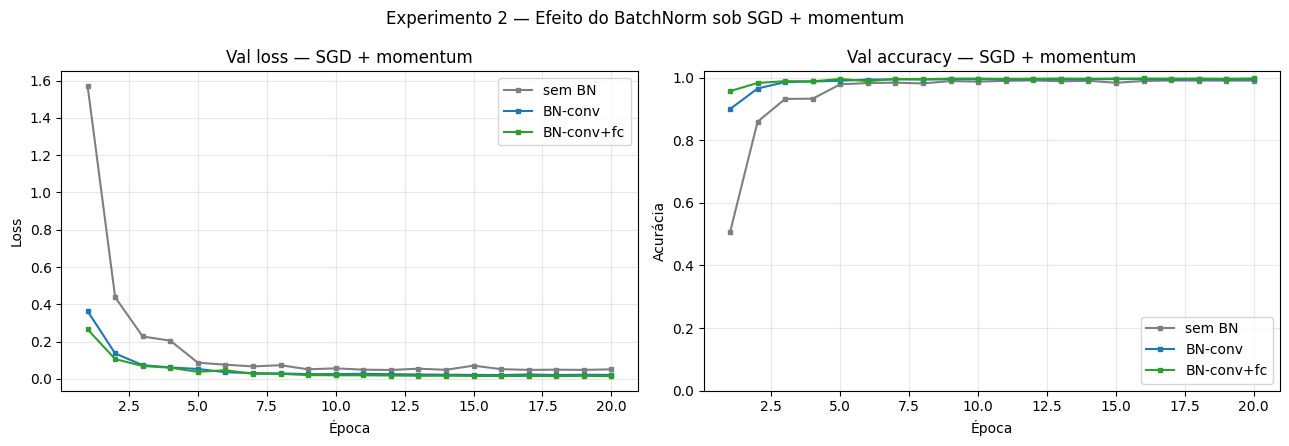

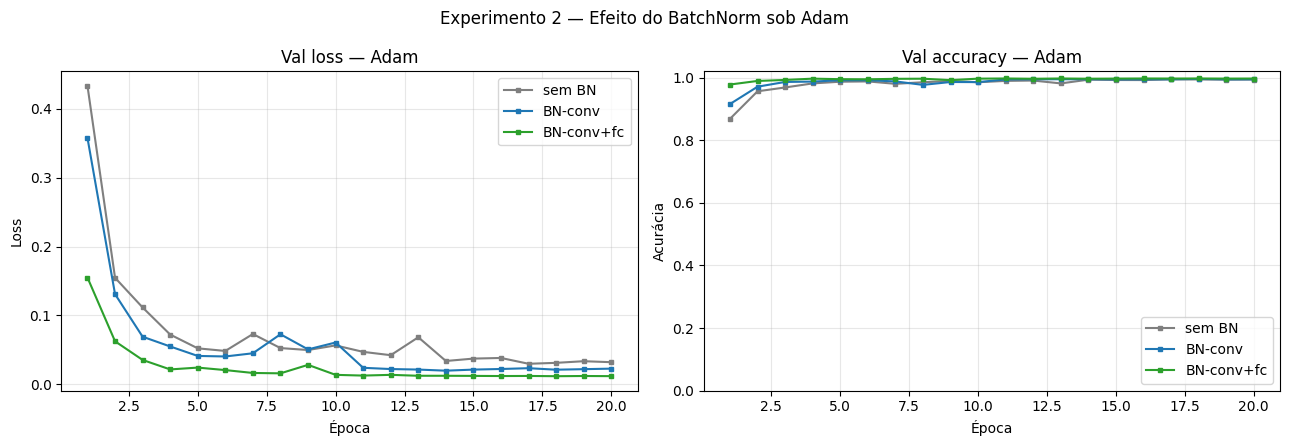

In [9]:
BN_COLORS = {"none": "tab:gray", "conv": "tab:blue", "conv+fc": "tab:green"}
BN_LABELS = {"none": "sem BN", "conv": "BN-conv", "conv+fc": "BN-conv+fc"}
OPT_LABELS = {"sgd_mom": "SGD + momentum", "adam": "Adam"}

epochs = range(1, NUM_EPOCHS + 1)

for opt_name in ("sgd_mom", "adam"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    runs_opt = [r for r in all_results.values() if r["opt_name"] == opt_name]
    for r in runs_opt:
        c = BN_COLORS[r["bn_mode"]]
        lbl = BN_LABELS[r["bn_mode"]]
        axes[0].plot(epochs, r["history"]["val_loss"], "s-", color=c, label=lbl, markersize=3)
        axes[1].plot(epochs, r["history"]["val_acc"],  "s-", color=c, label=lbl, markersize=3)

    axes[0].set_title(f"Val loss — {OPT_LABELS[opt_name]}")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title(f"Val accuracy — {OPT_LABELS[opt_name]}")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1.02)

    plt.suptitle(f"Experimento 2 — Efeito do BatchNorm sob {OPT_LABELS[opt_name]}")
    plt.tight_layout()
    plt.savefig(f"figs/exp2_curves_{opt_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Convergência: épocas para atingir limiares de val_acc

In [10]:
THRESHOLDS = [0.50, 0.80, 0.90, 0.95, 0.98]

def first_epoch_to_reach(acc_list, threshold):
    for i, a in enumerate(acc_list, start=1):
        if a >= threshold:
            return i
    return None

print(f"  {'Configuração':<30s} | " + " | ".join(f"  ≥{int(t*100)}%" for t in THRESHOLDS))
print("-" * 90)
for tag, r in all_results.items():
    label = f"{BN_LABELS[r['bn_mode']]:<12s} {OPT_LABELS[r['opt_name']]}"
    eps = [first_epoch_to_reach(r["history"]["val_acc"], t) for t in THRESHOLDS]
    cells_str = " | ".join(f"{('--' if e is None else f'ep {e:>2d}'):>6s}" for e in eps)
    print(f"  {label:<30s} | {cells_str}")

  Configuração                   |   ≥50% |   ≥80% |   ≥90% |   ≥95% |   ≥98%
------------------------------------------------------------------------------------------
  sem BN       SGD + momentum    |  ep  1 |  ep  2 |  ep  3 |  ep  5 |  ep  6
  sem BN       Adam              |  ep  1 |  ep  1 |  ep  2 |  ep  2 |  ep  4
  BN-conv      SGD + momentum    |  ep  1 |  ep  1 |  ep  2 |  ep  2 |  ep  3
  BN-conv      Adam              |  ep  1 |  ep  1 |  ep  1 |  ep  2 |  ep  3
  BN-conv+fc   SGD + momentum    |  ep  1 |  ep  1 |  ep  1 |  ep  1 |  ep  2
  BN-conv+fc   Adam              |  ep  1 |  ep  1 |  ep  1 |  ep  1 |  ep  2


## 9. Estabilidade: desvio padrão nas últimas 5 épocas

In [11]:
print(f"  {'Configuração':<30s} | {'val_acc final':>13s} | {'std últ 5':>10s} | {'spread últ 5':>12s}")
print("-" * 85)
for tag, r in all_results.items():
    label = f"{BN_LABELS[r['bn_mode']]:<12s} {OPT_LABELS[r['opt_name']]}"
    last5 = r["history"]["val_acc"][-5:]
    std5 = float(np.std(last5))
    spread = float(max(last5) - min(last5))
    print(f"  {label:<30s} | {last5[-1]:>13.4f} | {std5:>10.4f} | {spread:>12.4f}")

  Configuração                   | val_acc final |  std últ 5 | spread últ 5
-------------------------------------------------------------------------------------
  sem BN       SGD + momentum    |        0.9902 |     0.0006 |       0.0017
  sem BN       Adam              |        0.9938 |     0.0008 |       0.0023
  BN-conv      SGD + momentum    |        0.9947 |     0.0005 |       0.0015
  BN-conv      Adam              |        0.9946 |     0.0005 |       0.0013
  BN-conv+fc   SGD + momentum    |        0.9974 |     0.0004 |       0.0011
  BN-conv+fc   Adam              |        0.9970 |     0.0001 |       0.0004


## 10. Overfitting: gap train_acc − val_acc

In [15]:
print(f"  {'Configuração':<30s} | {'train final':>12s} | {'val final':>10s} | {'gap':>7s}")
print("-" * 75)
for tag, r in all_results.items():
    label = f"{BN_LABELS[r['bn_mode']]:<12s} {OPT_LABELS[r['opt_name']]}"
    t_final = r["history"]["train_acc"][-1]
    v_final = r["history"]["val_acc"][-1]
    print(f"  {label:<30s} | {t_final:>12.4f} | {v_final:>10.4f} | {t_final - v_final:>+7.4f}")

  Configuração                   |  train final |  val final |     gap
---------------------------------------------------------------------------
  sem BN       SGD + momentum    |       0.9997 |     0.9902 | +0.0094
  sem BN       Adam              |       1.0000 |     0.9938 | +0.0061
  BN-conv      SGD + momentum    |       1.0000 |     0.9947 | +0.0052
  BN-conv      Adam              |       1.0000 |     0.9946 | +0.0054
  BN-conv+fc   SGD + momentum    |       1.0000 |     0.9974 | +0.0026
  BN-conv+fc   Adam              |       1.0000 |     0.9970 | +0.0030


## 11. Avaliação no conjunto de teste

In [16]:
test_results = {}

for tag, r in all_results.items():
    model = CNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE, bn_mode=r["bn_mode"]).to(DEVICE)
    model.load_state_dict(torch.load(r["ckpt_path"], map_location=DEVICE))
    y_true, y_pred = predict_all(model, test_loader, DEVICE)
    assert y_pred.shape == (12630,)

    per_class_acc, _ = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
    global_acc = float((y_pred == y_true).mean())
    macro_acc = float(per_class_acc.mean())

    test_results[tag] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    label = f"{BN_LABELS[r['bn_mode']]:<12s} {OPT_LABELS[r['opt_name']]}"
    print(f"  {label:<30s} | global={global_acc:.4f} | macro={macro_acc:.4f}")

  sem BN       SGD + momentum    | global=0.8791 | macro=0.8462
  sem BN       Adam              | global=0.9101 | macro=0.8680
  BN-conv      SGD + momentum    | global=0.9138 | macro=0.8782
  BN-conv      Adam              | global=0.9164 | macro=0.8830
  BN-conv+fc   SGD + momentum    | global=0.9363 | macro=0.8993
  BN-conv+fc   Adam              | global=0.9339 | macro=0.8934


### 11.1 Resumo comparativo

In [18]:
print(f"  {'Configuração':<30s} | {'val (best)':>10s} | {'test glob':>9s} | {'test macro':>10s} | {'gap v→t':>8s} | {'pior cls':>8s} | {'tempo':>7s}")
print("-" * 110)
for tag, r in all_results.items():
    label = f"{BN_LABELS[r['bn_mode']]:<12s} {OPT_LABELS[r['opt_name']]}"
    tr = test_results[tag]
    worst = int(np.argmin(tr["per_class_acc"]))
    worst_acc = float(tr["per_class_acc"].min())
    gap_vt = tr["global_acc"] - r["best_val_acc"]
    print(f"  {label:<30s} | {r['best_val_acc']:>10.4f} | "
          f"{tr['global_acc']:>9.4f} | {tr['macro_acc']:>10.4f} | "
          f"{gap_vt:>+8.4f} | {worst:>2d}={worst_acc:.2f} | {r['elapsed_sec']:>6.1f}s")

  Configuração                   | val (best) | test glob | test macro |  gap v→t | pior cls |   tempo
--------------------------------------------------------------------------------------------------------------
  sem BN       SGD + momentum    |     0.9910 |    0.8791 |     0.8462 |  -0.1119 | 30=0.33 |  312.7s
  sem BN       Adam              |     0.9944 |    0.9101 |     0.8680 |  -0.0842 | 30=0.42 |  310.9s
  BN-conv      SGD + momentum    |     0.9955 |    0.9138 |     0.8782 |  -0.0817 |  0=0.53 |  307.6s
  BN-conv      Adam              |     0.9957 |    0.9164 |     0.8830 |  -0.0793 | 24=0.53 |  307.9s
  BN-conv+fc   SGD + momentum    |     0.9974 |    0.9363 |     0.8993 |  -0.0611 |  0=0.52 |  309.1s
  BN-conv+fc   Adam              |     0.9972 |    0.9339 |     0.8934 |  -0.0633 | 41=0.45 |  309.6s


### 11.2 Vista pareada — efeito isolado do BN

In [20]:
def get_test(opt_name, bn_mode):
    for tag, r in all_results.items():
        if r["opt_name"] == opt_name and r["bn_mode"] == bn_mode:
            return test_results[tag]
    return None

for opt_name in ("sgd_mom", "adam"):
    base = get_test(opt_name, "none")
    print(f"\n  {OPT_LABELS[opt_name]} — efeito do BN no teste:")
    print(f"    {'variante':<14s} | {'global':>7s} | {'Δ global':>10s} | {'macro':>7s} | {'Δ macro':>10s}")
    print("    " + "-" * 70)
    for bn_mode in ("none", "conv", "conv+fc"):
        tr = get_test(opt_name, bn_mode)
        d_glob = tr["global_acc"] - base["global_acc"]
        d_mac  = tr["macro_acc"]  - base["macro_acc"]
        marker = " (base)" if bn_mode == "none" else ""
        print(f"    {BN_LABELS[bn_mode]:<14s} | "
              f"{tr['global_acc']:>7.4f} | {d_glob:>+10.4f} | "
              f"{tr['macro_acc']:>7.4f} | {d_mac:>+10.4f}{marker}")


  SGD + momentum — efeito do BN no teste:
    variante       |  global |   Δ global |   macro |    Δ macro
    ----------------------------------------------------------------------
    sem BN         |  0.8791 |    +0.0000 |  0.8462 |    +0.0000 (base)
    BN-conv        |  0.9138 |    +0.0347 |  0.8782 |    +0.0321
    BN-conv+fc     |  0.9363 |    +0.0572 |  0.8993 |    +0.0531

  Adam — efeito do BN no teste:
    variante       |  global |   Δ global |   macro |    Δ macro
    ----------------------------------------------------------------------
    sem BN         |  0.9101 |    +0.0000 |  0.8680 |    +0.0000 (base)
    BN-conv        |  0.9164 |    +0.0063 |  0.8830 |    +0.0150
    BN-conv+fc     |  0.9339 |    +0.0238 |  0.8934 |    +0.0253


## 12. Acurácia por classe

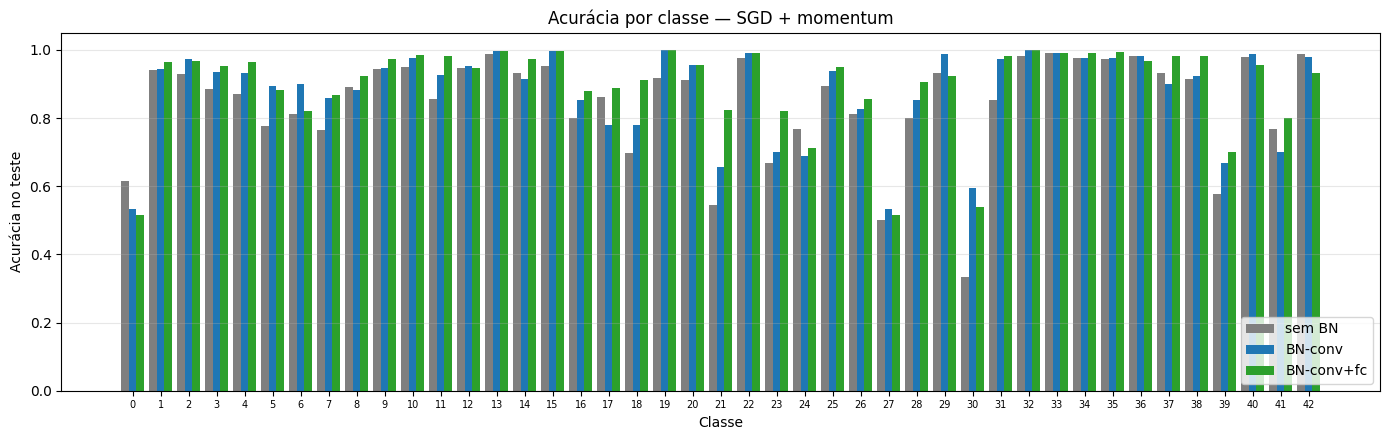

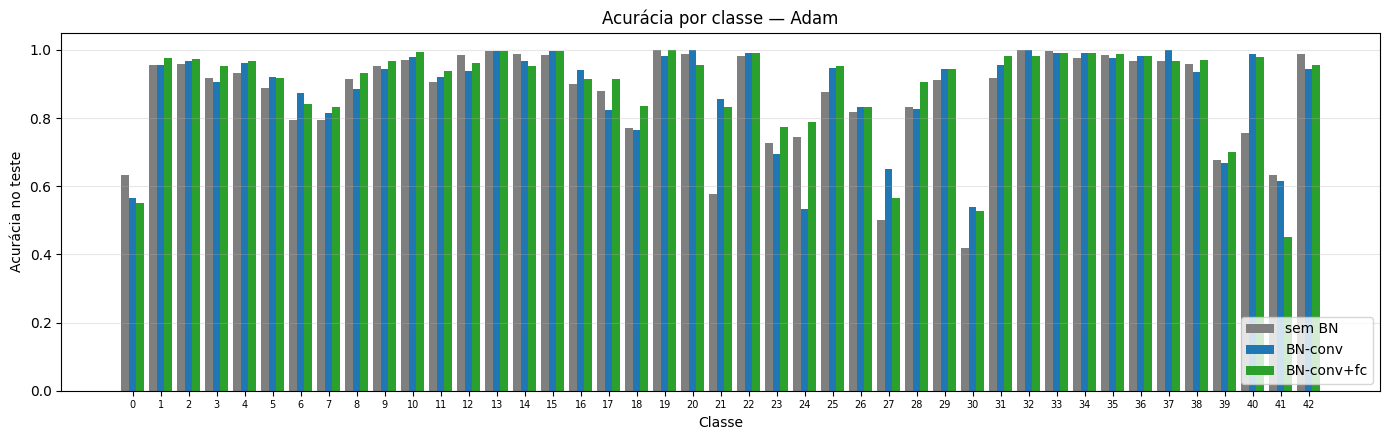

In [21]:
for opt_name in ("sgd_mom", "adam"):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    x = np.arange(NUM_CLASSES)
    width = 0.27
    for i, bn_mode in enumerate(("none", "conv", "conv+fc")):
        tr = get_test(opt_name, bn_mode)
        ax.bar(x + (i - 1) * width, tr["per_class_acc"], width,
               label=BN_LABELS[bn_mode], color=BN_COLORS[bn_mode])
    ax.set_xlabel("Classe"); ax.set_ylabel("Acurácia no teste")
    ax.set_title(f"Acurácia por classe — {OPT_LABELS[opt_name]}")
    ax.set_xticks(x); ax.set_xticklabels(x, fontsize=7)
    ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figs/exp2_per_class_{opt_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. As 5 classes mais difíceis do baseline

In [22]:
HARD_CLASSES = [0, 30, 27, 24, 21]

header = f"  {'Classe':<8s} | " + " | ".join(
    f"{BN_LABELS[bn]:<10s} {OPT_LABELS[op][:4]}" for op in ("sgd_mom", "adam") for bn in ("none", "conv", "conv+fc")
)
print(header)
print("-" * len(header))
for c in HARD_CLASSES:
    row_vals = []
    for op in ("sgd_mom", "adam"):
        for bn in ("none", "conv", "conv+fc"):
            row_vals.append(get_test(op, bn)["per_class_acc"][c])
    row = f"  cls {c:>2d}  | " + " | ".join(f"{v:>15.4f}" for v in row_vals)
    print(row + f"  ({GTSRB_CLASSES[c]})")

print()
print("  Média sobre as 5 classes difíceis:")
for op in ("sgd_mom", "adam"):
    for bn in ("none", "conv", "conv+fc"):
        mean_hard = float(np.mean([get_test(op, bn)["per_class_acc"][c] for c in HARD_CLASSES]))
        print(f"    {OPT_LABELS[op]:<18s} {BN_LABELS[bn]:<14s} = {mean_hard:.4f}")

  Classe   | sem BN     SGD  | BN-conv    SGD  | BN-conv+fc SGD  | sem BN     Adam | BN-conv    Adam | BN-conv+fc Adam
----------------------------------------------------------------------------------------------------------------------
  cls  0  |          0.6167 |          0.5333 |          0.5167 |          0.6333 |          0.5667 |          0.5500  (Speed limit (20km/h))
  cls 30  |          0.3333 |          0.5933 |          0.5400 |          0.4200 |          0.5400 |          0.5267  (Beware of ice/snow)
  cls 27  |          0.5000 |          0.5333 |          0.5167 |          0.5000 |          0.6500 |          0.5667  (Pedestrians)
  cls 24  |          0.7667 |          0.6889 |          0.7111 |          0.7444 |          0.5333 |          0.7889  (Road narrows right)
  cls 21  |          0.5444 |          0.6556 |          0.8222 |          0.5778 |          0.8556 |          0.8333  (Double curve)

  Média sobre as 5 classes difíceis:
    SGD + momentum     sem BN      

### 13.1 Δ acurácia das classes difíceis com BN

In [24]:
for op in ("sgd_mom", "adam"):
    base_vec = get_test(op, "none")["per_class_acc"]
    print(f"\n  {OPT_LABELS[op]} — Δ por classe (variante − sem BN):")
    print(f"    {'cls':<5s} | {'sem BN':>7s} | {'Δ BN-conv':>11s} | {'Δ BN-conv+fc':>13s}  classe")
    print("    " + "-" * 80)
    for c in HARD_CLASSES:
        v_conv = get_test(op, "conv")["per_class_acc"][c]
        v_fc   = get_test(op, "conv+fc")["per_class_acc"][c]
        print(f"    {c:>4d}  | {base_vec[c]:>7.4f} | "
              f"{v_conv - base_vec[c]:>+11.4f} | {v_fc - base_vec[c]:>+13.4f}  "
              f"({GTSRB_CLASSES[c]})")


  SGD + momentum — Δ por classe (variante − sem BN):
    cls   |  sem BN |   Δ BN-conv |  Δ BN-conv+fc  classe
    --------------------------------------------------------------------------------
       0  |  0.6167 |     -0.0833 |       -0.1000  (Speed limit (20km/h))
      30  |  0.3333 |     +0.2600 |       +0.2067  (Beware of ice/snow)
      27  |  0.5000 |     +0.0333 |       +0.0167  (Pedestrians)
      24  |  0.7667 |     -0.0778 |       -0.0556  (Road narrows right)
      21  |  0.5444 |     +0.1111 |       +0.2778  (Double curve)

  Adam — Δ por classe (variante − sem BN):
    cls   |  sem BN |   Δ BN-conv |  Δ BN-conv+fc  classe
    --------------------------------------------------------------------------------
       0  |  0.6333 |     -0.0667 |       -0.0833  (Speed limit (20km/h))
      30  |  0.4200 |     +0.1200 |       +0.1067  (Beware of ice/snow)
      27  |  0.5000 |     +0.1500 |       +0.0667  (Pedestrians)
      24  |  0.7444 |     -0.2111 |       +0.0444  (Road

### 13.2 Quem é a nova pior classe?

In [25]:
for op in ("sgd_mom", "adam"):
    for bn in ("none", "conv", "conv+fc"):
        tr = get_test(op, bn)
        sorted_idx = np.argsort(tr["per_class_acc"])
        bottom5 = sorted_idx[:5]
        info = ", ".join(f"{c}({tr['per_class_acc'][c]:.2f})" for c in bottom5)
        print(f"  {OPT_LABELS[op]:<18s} {BN_LABELS[bn]:<14s} | bottom5: {info}")

  SGD + momentum     sem BN         | bottom5: 30(0.33), 27(0.50), 21(0.54), 39(0.58), 0(0.62)
  SGD + momentum     BN-conv        | bottom5: 0(0.53), 27(0.53), 30(0.59), 21(0.66), 39(0.67)
  SGD + momentum     BN-conv+fc     | bottom5: 0(0.52), 27(0.52), 30(0.54), 39(0.70), 24(0.71)
  Adam               sem BN         | bottom5: 30(0.42), 27(0.50), 21(0.58), 0(0.63), 41(0.63)
  Adam               BN-conv        | bottom5: 24(0.53), 30(0.54), 0(0.57), 41(0.62), 27(0.65)
  Adam               BN-conv+fc     | bottom5: 41(0.45), 30(0.53), 0(0.55), 27(0.57), 39(0.70)


## 14. Salvar predições

In [26]:
for tag, tr in test_results.items():
    r = all_results[tag]
    out_path = f"results/predicoes_exp2_{tag}.csv"
    exp_name = f"Exp2 {BN_LABELS[r['bn_mode']]} + {OPT_LABELS[r['opt_name']]} | img=32 | 20 epochs"
    save_predictions(tr["y_pred"], out_path, experiment_name=exp_name)
    print(f"  {out_path}  ({len(tr['y_pred'])} predições)")

  results/predicoes_exp2_sem_BN__sgd_mom.csv  (12630 predições)
  results/predicoes_exp2_sem_BN__adam.csv  (12630 predições)
  results/predicoes_exp2_BN_conv__sgd_mom.csv  (12630 predições)
  results/predicoes_exp2_BN_conv__adam.csv  (12630 predições)
  results/predicoes_exp2_BN_conv_fc__sgd_mom.csv  (12630 predições)
  results/predicoes_exp2_BN_conv_fc__adam.csv  (12630 predições)
